---
title: "Efecto del *Inflation Targeting* sobre la inversión doméstica en México (2001): un enfoque de control sintético"
author:
  - name: "[Tu nombre]"
    affiliation: "Econometría II"
date: today
date-format: long
abstract: |
  México adoptó formalmente el régimen de *Inflation Targeting* (IT) en 2001. La teoría
  predice que el anclaje de expectativas debería reducir la incertidumbre macroeconómica
  y estimular la inversión, pero la evidencia empírica es heterogénea. Este trabajo estima
  el efecto causal de la adopción del IT sobre la formación bruta de capital fijo en México
  mediante el método de control sintético (Abadie et al., 2010), usando un panel del
  *World Development Indicators* (1984–2023) y un *donor pool* de economías no-OCDE.
  Frente a su contrafactual sintético, la inversión mexicana fue persistentemente menor
  tras la adopción del IT —del orden de −3.7 puntos del PIB en promedio—, en línea con la
  evidencia previa. No obstante, la inferencia por placebos (pseudo *p-value* ≈ 0.75) no
  permite rechazar la hipótesis nula al nivel convencional, por lo que la conclusión es
  matizada: el efecto adverso es económicamente relevante pero estadísticamente no concluyente.
keywords: [inflation targeting, control sintético, inversión, México, política monetaria]
jupyter: python3
---

In [1]:
#| label: setup
#| include: false
import sys
from pathlib import Path

# Hace importable el motor de análisis (script/scm.py) sin importar el cwd del render.
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "script"))

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150

# Introducción

México adoptó formalmente el régimen de *Inflation Targeting* (IT) en 2001, tras la crisis del peso de 1994–1995 y la reforma que otorgó autonomía constitucional al Banco de México (Ley de Autonomía de 1994). El IT busca anclar las expectativas de inflación mediante un objetivo explícito y público, reduciendo la incertidumbre macroeconómica. En teoría, esa reducción de incertidumbre debería estimular la inversión doméstica al disminuir la prima de riesgo y facilitar la planificación de largo plazo [@svensson2010].

Sin embargo, la evidencia empírica no es concluyente. @mccloud2022, usando el método de control sintético para 29 países, encuentra que en 21 de ellos **no hubo efecto significativo** del IT sobre la inversión, y que para México el efecto fue **negativo** —de hasta 7.48 puntos porcentuales del PIB en 2008—, atribuible a la credibilidad débil del banco central y a restricciones del sistema financiero doméstico. México aparece, además, como un caso recurrentemente difícil de modelar en la literatura de control sintético cuando el resultado de interés es la inflación.

**Pregunta de investigación.** ¿Cuál fue el efecto causal de la adopción del IT en 2001 sobre la inversión doméstica agregada en México?

Esta pregunta es relevante por tres razones. Primero, por su pertinencia para la política: México mantiene el IT como marco de política monetaria, y entender su efecto sobre la inversión —motor del crecimiento de largo plazo— es crucial para evaluar su desempeño. Segundo, porque México es un caso atípico: uno de los pocos países donde la literatura encuentra un efecto negativo significativo; si el IT desincentiva la inversión en economías con credibilidad débil, el diseño institucional importa tanto como el régimen mismo. Tercero, porque permite actualizar la evidencia: McCloud usa datos hasta 2017, mientras que nuestra ventana se extiende a 2023, cubriendo la pandemia de COVID-19 y permitiendo evaluar si el efecto persistió.

**Hipótesis de trabajo.** Contrastamos dos hipótesis:

- **H0 (efecto nulo):** la adopción del IT en 2001 no tuvo efecto sobre la formación bruta de capital fijo en México; la trayectoria observada es indistinguible de la de su contrafactual sintético.
- **H1 (alternativa):** el IT tuvo un efecto **negativo** sobre la inversión doméstica. El mecanismo propuesto por @mccloud2022 —credibilidad débil del banco central, expectativas de inflación persistentemente altas, restricciones del sistema financiero— implica que la inversión mexicana post-2001 es sistemáticamente menor que la de su contrafactual sin IT.

La direccionalidad negativa de H1 está motivada por la evidencia previa [@mccloud2022], por la dificultad del Banco de México para anclar expectativas en la primera década del régimen [@bambe2023] y por la baja profundidad del sistema financiero mexicano.

**Contribución.** Este trabajo no replica mecánicamente a McCloud, sino que toma su estrategia de identificación como punto de partida para responder una pregunta propia sobre México. Aportamos: (i) datos actualizados a 2023; (ii) una especificación con *donor pool* restringido a economías no-OCDE, que evita que economías avanzadas dominen el contrafactual; (iii) membresía OCDE histórica (variable en el tiempo) en lugar de una *dummy* constante; y (iv) verificaciones de robustez sobre la ventana pre-tratamiento y el conjunto de predictores. El resto del documento se organiza así: el marco teórico (Sección 2), los datos (Sección 3), el análisis descriptivo (Sección 4), la estrategia empírica (Sección 5), los resultados (Sección 6), la discusión (Sección 7) y las conclusiones (Sección 8).

# Marco teórico y revisión de literatura

## El *Inflation Targeting* como régimen de política monetaria

El *Inflation Targeting* (IT) es un régimen de política monetaria caracterizado por tres pilares: (i) el anuncio público de una meta numérica de inflación, (ii) un marco institucional que otorga independencia operativa al banco central, y (iii) un compromiso de transparencia y rendición de cuentas que obliga a la autoridad monetaria a explicar sus decisiones y sus desviaciones respecto a la meta [@svensson1998; @svensson2010]. A diferencia de regímenes basados en metas intermedias —como el crecimiento de agregados monetarios o el tipo de cambio fijo—, el IT opera bajo el principio de *forecast targeting*: el banco central utiliza sus propios pronósticos de inflación como variable intermedia, ajustando el instrumento de política (típicamente la tasa de interés de corto plazo) para minimizar la distancia entre el pronóstico condicional de inflación y la meta anunciada [@svensson1998].

Desde la teoría, el canal de transmisión del IT hacia la inversión doméstica opera a través de la reducción de incertidumbre macroeconómica [@svensson2010]. Una meta de inflación creíble y públicamente comunicada ancla las expectativas de los agentes: los inversionistas pueden planificar a largo plazo con menor incertidumbre sobre la trayectoria futura de precios, lo que reduce la prima de riesgo incorporada en las decisiones de inversión y, en principio, estimula la formación de capital fijo. Al estabilizar la inflación y su variabilidad, el IT también reduce la volatilidad del producto y del tipo de cambio real, canales complementarios que favorecerían la inversión [@svensson2010].

Sin embargo, el propio @svensson2010 advierte un hallazgo central para este trabajo: la evidencia revisada en el *Handbook of Monetary Economics* muestra que el IT **no tiene un efecto significativo sobre el crecimiento económico**, la productividad o el empleo. Citando a Ball y Sheridan (2005) para países OCDE y a Gonçalves y Salles (2008) para economías emergentes, Svensson concluye que el IT es neutral en crecimiento y positivo en estabilización de inflación, pero **no estimula la actividad real por encima de lo que lograría un régimen monetario alternativo igualmente disciplinado**. Esta distinción —entre estabilizar precios y estimular la inversión— es el punto de partida de nuestra investigación: si el IT es, en el mejor de los casos, neutral para el crecimiento, la pregunta relevante no es si el IT *debería* funcionar en teoría, sino bajo qué condiciones institucionales y estructurales lo hace —o no— en la práctica.

## Evidencia empírica: ¿funciona el IT en la práctica?

La literatura empírica sobre los efectos del IT es extensa, pero sus conclusiones son notablemente heterogéneas. Esa heterogeneidad no es una debilidad de la literatura sino el reflejo de una realidad: el IT no es una política uniforme sino un marco institucional cuyo desempeño depende del contexto en el que se implementa.

**Evidencia favorable en economías avanzadas.** Los primeros estudios de caso con control sintético encontraron efectos positivos en las economías pioneras. @brito2021, utilizando control sintético multivariado con series de tiempo, reportan que en Nueva Zelanda, Canadá, Reino Unido, Suecia y Australia el IT redujo la inflación sin sacrificar el producto en los primeros años de adopción, y permitió mayor crecimiento sin aceleración de precios en el largo plazo. @barbosa2018 confirman el patrón para un panel de 24 economías industriales: el IT generó ganancias económicamente importantes —menor inflación y mayor crecimiento respecto al contrafactual sintético— durante la década de 1990. Estos resultados son consistentes con la predicción de Svensson: cuando el IT se implementa en economías con instituciones sólidas, mercados financieros profundos y bancos centrales con credibilidad establecida, el anclaje de expectativas opera eficazmente.

**Evidencia escéptica.** En el extremo opuesto, @lin2007 encuentran que el IT no tuvo efecto significativo sobre el nivel ni la variabilidad de la inflación en una muestra de economías industrializadas; su conclusión —que el IT es en buena medida *window dressing*, donde las acciones importan más que los anuncios— estableció un precedente de escepticismo. Más recientemente, @bhalla2023, en un *working paper* del FMI, concluyen que el IT **no es necesario ni suficiente** para lograr baja inflación. Su hallazgo más provocador es que gran parte del éxito aparente del IT se debe a "regresión a la media": los países adoptan IT tras episodios de inflación excepcionalmente alta, y la subsecuente reducción habría ocurrido en buena medida incluso sin el cambio de régimen. Bhalla et al. tampoco encuentran evidencia de que el IT mejore el crecimiento.

**El IT funciona distinto en desarrollados y emergentes.** @millerFangEren documentan un patrón clave en su revisión: en economías desarrolladas el IT no genera mejoras significativas de largo plazo en inflación o crecimiento, mientras que en emergentes sí se observa un efecto positivo y duradero en la reducción de la inflación. El IT sería más efectivo allí donde más se necesita —economías con historial inflacionario—, pero esta literatura se ha concentrado en la inflación como variable de resultado; el canal hacia la inversión real ha recibido menos atención sistemática.

**México como caso problemático recurrente.** Un hallazgo transversal en la literatura con control sintético es que México aparece sistemáticamente como un caso difícil de modelar cuando el *outcome* es la inflación. @lee2011, en una aplicación pionera del método a economías emergentes, no logró un ajuste pre-tratamiento satisfactorio para la trayectoria inflacionaria mexicana y no pudo realizar inferencia. @duncan2024, en un estudio del Banco de la Reserva Federal de Dallas, excluyen explícitamente a México de sus resultados finales: imponen umbrales de ajuste pre-tratamiento (RMSPE inferior a 3 puntos porcentuales y razón MAPE/desviación estándar inferior a 0.5) y México los rebasa con un RMSPE de 5.45 y una razón de 0.53. En la misma línea, @bhalla2023 reportan para México un RMSPE de 7.84 cuando el *outcome* es la inflación —dos órdenes de magnitud peor que el ajuste que se obtiene usando la inversión como *outcome*. Esta recurrencia sugiere que la trayectoria inflacionaria mexicana ha sido tan volátil y singular —marcada por las crisis de los años ochenta y noventa— que ningún control sintético la reproduce satisfactoriamente. Es una de las motivaciones para usar la inversión doméstica como *outcome*, siguiendo a @mccloud2022: la formación bruta de capital fijo ofrece un ajuste pre-tratamiento sustancialmente mejor.

## El canal de inversión doméstica

Dos trabajos recientes abordan directamente la pregunta que nos ocupa: ¿responde la inversión doméstica a la adopción del IT?

@mccloud2022 aplica el control sintético a una muestra de 104 países (29 tratados con IT, 75 de control) para 1984–2017, usando la formación bruta de capital fijo como *outcome*. Su hallazgo es doble. Primero, en 21 de los 29 países que adoptaron IT **no se encontró efecto significativo** sobre la inversión —consistente con la hipótesis de inatención racional: los agentes no modifican sus decisiones de inversión ante un cambio de régimen monetario si no perciben que altera fundamentalmente el entorno macroeconómico. Segundo, en 6 países el efecto fue **negativo y significativo**, entre ellos México, donde la inversión como porcentaje del PIB fue hasta 7.48 puntos porcentuales menor en 2008 de lo que habría sido sin IT (RMSPE pre-tratamiento de 0.11, pseudo *p-value* entre 0.080 y 0.093).

Conviene precisar cómo McCloud somete a robustez este resultado, porque define el encuadre de nuestra propia especificación. McCloud estratifica su muestra de dos formas. En el primer corte separa países OCDE de no-OCDE y empareja tratados con controles del mismo grupo; como México es miembro de la OCDE en su clasificación (ingresó en 1994), queda en el grupo OCDE y su ajuste se deteriora drásticamente (RMSPE de 1.41). En el segundo corte separa economías desarrolladas de "en desarrollo"; allí México cae en el grupo en desarrollo y recupera un buen ajuste (RMSPE de 0.12), confirmándose el efecto adverso del IT junto con Colombia, Ghana, Guatemala, Paraguay y Filipinas [@mccloud2022]. McCloud no reporta la composición ni los pesos del sintético en ninguno de estos cortes de robustez. Esta distinción importa para nuestra estrategia (Sección 5): nuestro *donor pool* restringido a economías no-OCDE es una decisión metodológica **propia**, en el espíritu de la estratificación de McCloud, cuyo comparador con buen ajuste para México es su submuestra de países en desarrollo.

McCloud atribuye el caso mexicano a dos factores. El primero es la **falta de credibilidad del banco central**: las expectativas de inflación en México permanecieron cerca del techo de la banda objetivo incluso tras una década de IT, lo que sugiere que el anclaje de expectativas —el mecanismo central del IT según Svensson— nunca se materializó plenamente. Citando al FMI (2020), McCloud documenta que "la inflación observada y las expectativas de inflación en México se han mantenido más cerca del rango superior de la meta a pesar de la reducción considerable en los niveles y la volatilidad de la inflación en la era post-IT" [@mccloud2022]. El segundo factor es estructural: apoyándose en @boydsmith1998 y en el FMI (2020), McCloud argumenta que los países con **sistemas financieros menos desarrollados** se ven más afectados adversamente por la inflación, y señala como canales relevantes para México la estabilidad financiera, la dinámica de flujos de capital y la inclusión financiera [@mccloud2022].

@bambe2023 complementa este análisis. Usando *Propensity Score Matching* y regresiones de función de control para 62 países en desarrollo durante 1990–2019, encuentra que el IT incrementa la inversión privada entre 2.80 y 3.26 puntos porcentuales del PIB en promedio —pero ese efecto positivo **desaparece** cuando el banco central se desvía sistemáticamente de la meta. Bambe identifica a México y Colombia como casos donde la desviación promedio de la meta (1.35% y 1.64%, respectivamente) se sitúa muy por encima del promedio de la muestra de países IT (1.18%). El mecanismo es claro: la credibilidad no es un atributo binario que se adquiere con la adopción formal del régimen, sino una variable continua que se construye —o se erosiona— con el desempeño observado del banco central.

## ¿Por qué México podría ser un caso atípico?

La confluencia de la literatura teórica y empírica sugiere que México ocupa una posición peculiar en el mapa de países que adoptaron IT. Tres factores convergen.

**Credibilidad institucional incompleta.** Aunque México reformó la Ley del Banco de México en 1994 —otorgándole autonomía constitucional— y adoptó formalmente el IT en 2001, la credibilidad del banco central se construyó gradualmente. La inflación se mantuvo cerca del techo de la banda durante gran parte de los años 2000 y las expectativas de inflación tardaron años en converger hacia la meta del 3% [@mccloud2022; @bambe2023]. Este desfase entre adopción formal y credibilidad efectiva es precisamente el escenario en el que la teoría predice que el IT no logrará anclar expectativas ni estimular la inversión [@svensson2010].

**Estructura del sistema financiero.** El sistema financiero mexicano se caracteriza por una baja penetración del crédito bancario al sector privado. McCloud no cuantifica esta penetración, pero los datos del Banco Mundial [@wdi2024] confirman que el crédito doméstico al sector privado en México ha sido históricamente bajo en comparación con economías de ingreso medio comparables. Por los canales que identifican @boydsmith1998 y McCloud —estabilidad financiera, flujos de capital, inclusión financiera—, una intermediación financiera débil limita que la estabilidad de precios se traduzca en mayor inversión productiva.

**Exclusión recurrente en estudios SCM de inflación.** Como se documentó arriba, México es un caso que la literatura con control sintético no ha podido modelar cuando el *outcome* es la inflación: @lee2011 no logró ajuste pre-tratamiento, @duncan2024 lo excluyó por rebasar los umbrales de ajuste (RMSPE 5.45) y @bhalla2023 obtuvieron un RMSPE de 7.84. Esta recurrencia sugiere que la trayectoria macroeconómica mexicana es genuinamente más volátil que la de otras economías emergentes, lo que convierte a México en un caso de estudio particularmente informativo cuando se elige un *outcome* —la inversión— que sí admite un buen ajuste pre-tratamiento.

**Implicación para esta investigación.** Si el IT es neutral en crecimiento en el mejor de los casos [@svensson2010], si su efectividad depende de la credibilidad con que se implementa [@bambe2023], y si México presenta debilidades institucionales y estructurales que comprometen esa credibilidad [@mccloud2022], entonces la hipótesis de que el IT tuvo un efecto nulo o incluso negativo sobre la inversión doméstica mexicana está sólidamente motivada por la literatura. Las secciones siguientes someten esta hipótesis a contrastación empírica con datos actualizados a 2023 y una especificación que se beneficia de dos décadas de aplicaciones del control sintético al estudio del IT.

# Datos

**Fuente y cobertura.** Los datos provienen del *World Development Indicators* del Banco Mundial [@wdi2024], descargados vía su API pública. El panel cubre el período 1984–2023 (40 años). Tras filtrar países sin información suficiente en el período pre-tratamiento, la muestra de trabajo contiene 108 países: 25 economías que adoptaron IT y 83 economías no-OCDE que no lo adoptaron, las cuales conforman el *donor pool* del control sintético.

**Variable de resultado.** El *outcome* es la **formación bruta de capital fijo** como porcentaje del PIB (WDI `NE.GDI.TOTL.ZS`), nuestra medida de inversión doméstica agregada. Seguimos a @mccloud2022 en esta elección: la inversión admite un ajuste pre-tratamiento sustancialmente mejor que la inflación, que es el *outcome* habitual en la literatura de IT pero que en el caso mexicano produce ajustes deficientes (Sección 2).

**Predictores.** El modelo usa como predictores el crecimiento del PIB (`NY.GDP.MKTP.KD.ZG`), el logaritmo de la población (`SP.POP.TOTL`), la inflación medida por el deflactor del PIB (`NY.GDP.DEFL.KD.ZG`) y un indicador de país exportador de petróleo, además de los rezagos anuales del propio *outcome* durante 1990–2000. El ahorro bruto (`NY.GNS.ICTR.ZS`) se evalúa solo como verificación de robustez (Sección 6), porque su alta proporción de valores faltantes reduce el *donor pool*.

**Clasificación del IT.** La fecha de adopción de cada país se codificó a partir de la literatura y de la clasificación del FMI; para México se fija en 2001, año de adopción formal del esquema de objetivos de inflación por el Banco de México.

**Membresía OCDE histórica.** A diferencia de una *dummy* constante, codificamos la pertenencia a la OCDE por año de adhesión efectiva. Esto es relevante para el *donor pool*: un país solo se considera donante válido si **no** era miembro de la OCDE durante el período pre-tratamiento (1990–2000). El detalle de esta construcción se discute en la Sección 5.

**Construcción de la muestra.** Se conservan los países con datos completos en todos los predictores y el *outcome* durante 1990–2000, garantizando un panel balanceado en el período de optimización. El código de construcción y estimación reside en `script/scm.py`; la descarga y limpieza de datos se documenta por separado en `script/00_data_pipeline.ipynb` y produce el archivo congelado `data/panel_mccloud_mexico.csv`, que es el insumo de este documento.

# Análisis descriptivo

In [2]:
#| label: load-data
#| include: false
import scm
df = scm.load_panel()

La @fig-mexico-series muestra la trayectoria de la formación bruta de capital fijo en México entre 1984 y 2023. La línea roja marca el año de adopción del IT (2001).

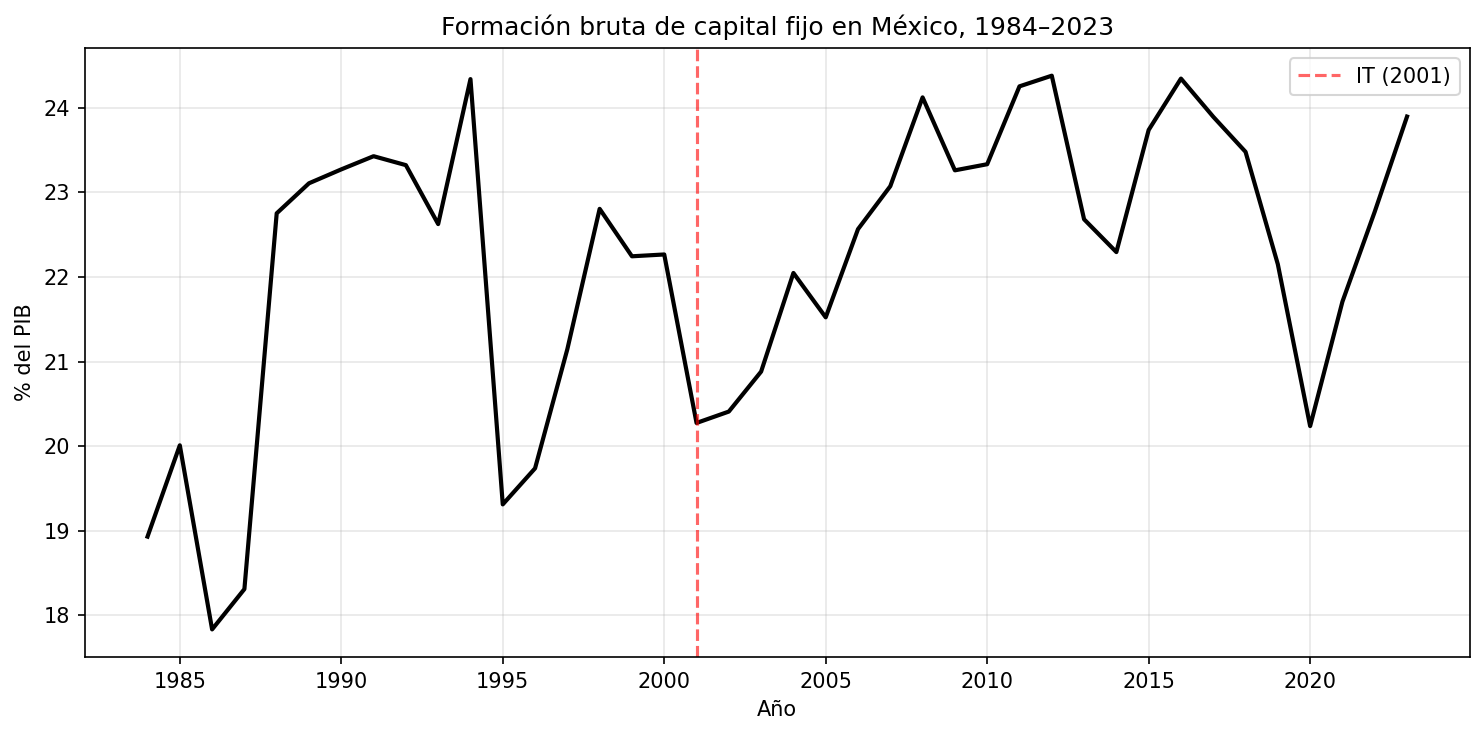

In [3]:
#| label: fig-mexico-series
#| fig-cap: "Formación bruta de capital fijo en México, 1984–2023 (% del PIB)."
scm.fig_mexico_series(df)
plt.show()

Una primera lectura ingenua compararía la inversión promedio antes y después de 2001. La @tbl-prepost reporta esas medias.

In [4]:
#| label: tbl-prepost
#| tbl-cap: "Inversión media de México, pre vs post adopción del IT."
from IPython.display import Markdown
Markdown(scm.prepost_summary(df).to_markdown())

| Periodo         |   Inversión media (% PIB) |
|:----------------|--------------------------:|
| Pre-IT (<2001)  |                     21.5  |
| Post-IT (≥2001) |                     22.66 |
| Diferencia      |                      1.17 |

El cuadro revela una aparente paradoja: la inversión promedio fue **mayor** después de 2001 que antes. Concluir de aquí que el IT favoreció la inversión sería, sin embargo, un error de inferencia. La comparación pre/post no controla por lo que habría ocurrido con la inversión en ausencia del IT —es decir, por el contrafactual—. Factores globales como el auge de materias primas de los 2000, el ciclo de liquidez internacional o la propia recuperación tras la crisis de 1995 pudieron elevar la inversión con independencia del régimen monetario. La pregunta causal correcta no es "¿subió la inversión tras el IT?", sino "¿subió **más o menos** de lo que habría subido sin IT?". Responderla requiere construir un contrafactual creíble, que es justamente lo que provee el método de control sintético.

# Estrategia empírica

**El método de control sintético.** El control sintético [@abadie2003; @abadie2010] construye un contrafactual para la unidad tratada —México— como una combinación lineal ponderada de unidades de control que no recibieron el tratamiento. Los pesos $w_j \geq 0$, con $\sum_j w_j = 1$, se eligen de modo que el "México sintético" reproduzca lo mejor posible la trayectoria pre-tratamiento del *outcome* y de los predictores de la inversión. La idea intuitiva es construir un "México sin IT" a partir de países que, combinados, se parecen a México antes de 2001; el efecto del IT se estima como la diferencia (el *gap*) entre la inversión observada de México y la de su sintético después de 2001.

**Predictores y ventana.** El sintético se ajusta sobre el período pre-tratamiento 1990–2000 usando como predictores las cuatro covariables descritas en la Sección 3 más los once rezagos anuales del *outcome*. La ventana inicia en 1990 —y no en 1984— porque la crisis de la deuda de los años ochenta introduce valores faltantes y un ajuste pre-tratamiento notablemente peor; la Sección 6 documenta esta decisión como verificación de robustez.

**Justificación del *donor pool* no-OCDE.** Restringimos el conjunto de donantes a economías que no eran miembros de la OCDE durante el período pre-tratamiento. La razón es metodológica: con el *donor pool* completo, economías avanzadas —en particular Estados Unidos— pueden recibir pesos elevados y dominar el contrafactual, pese a no ser comparables estructuralmente con México. Restringir a no-OCDE produce un sintético compuesto por economías de ingreso medio y bajo, más comparables. Esta es una decisión propia, en el espíritu de la estratificación que @mccloud2022 explora en su análisis de robustez; conviene recordar (Sección 2) que en McCloud el comparador con buen ajuste para México es su submuestra de países *en desarrollo* —no la de no-OCDE—, porque en su clasificación México figura como miembro de la OCDE.

**Inferencia por placebos in-space.** Como el control sintético se aplica a una sola unidad tratada, los errores estándar convencionales no son apropiados [@adhikari2022]. La inferencia se realiza mediante placebos *in-space* [@firpo2018]: se reasigna falsamente el tratamiento a cada país del *donor pool* y se estima su *gap* placebo. Si el efecto estimado para México es grande en relación con la distribución de los efectos placebo, se interpreta como evidencia de un efecto genuino. El pseudo *p-value* es la proporción de placebos cuyo efecto iguala o supera (en magnitud) al de México. Siguiendo la regla de @adhikari2022, un pseudo *p-value* superior a 0.10 indica que **no** hay evidencia estadísticamente significativa de un efecto al nivel convencional. Adhikari advierte, además, que con un *donor pool* pequeño la potencia de esta inferencia es limitada —una salvedad pertinente para nuestra interpretación (Sección 7).

**Implementación.** La estimación se realiza en Python con la librería `pysyncon` (optimización Nelder-Mead). Todo el cómputo de esta sección es reproducible desde el módulo `script/scm.py` a partir del CSV congelado, sin necesidad de acceder a la API del Banco Mundial.

# Resultados

In [5]:
#| label: estimate-base
#| include: false
res = scm.estimate()              # especificación base: non-OECD, 1990–2000
rmspe = res.rmspe

**El México sintético.** El control sintético de México se compone de 15 economías no-OCDE con peso positivo (@tbl-weights). El ajuste pre-tratamiento es excelente: la raíz del error cuadrático medio de predicción (RMSPE) es 0.1074, comparable al 0.11–0.12 que @mccloud2022 reporta para México en su muestra de buen ajuste.

In [6]:
#| label: tbl-weights
#| tbl-cap: "Composición del México sintético (pesos > 0.001), especificación non-OECD."
from IPython.display import Markdown
w = res.weights[res.weights > 0.001].sort_values(ascending=False)
wt = w.rename("Peso").to_frame()
wt.index.name = "País donante"
Markdown(wt.to_markdown())

| País donante   |   Peso |
|:---------------|-------:|
| Mongolia       |  0.179 |
| Mauritius      |  0.157 |
| Bolivia        |  0.129 |
| Madagascar     |  0.109 |
| Mauritania     |  0.097 |
| Senegal        |  0.087 |
| Honduras       |  0.062 |
| Botswana       |  0.049 |
| Chad           |  0.036 |
| Sudan          |  0.025 |
| Bangladesh     |  0.023 |
| Bahamas, The   |  0.02  |
| Guinea-Bissau  |  0.017 |
| Tanzania       |  0.006 |
| Kuwait         |  0.005 |

**Trayectoria observada vs contrafactual.** La @fig-path muestra la inversión observada de México frente a la de su sintético. Ambas trayectorias se superponen estrechamente antes de 2001 (reflejo del buen ajuste) y se separan después: la inversión observada queda sistemáticamente **por debajo** de la del contrafactual.

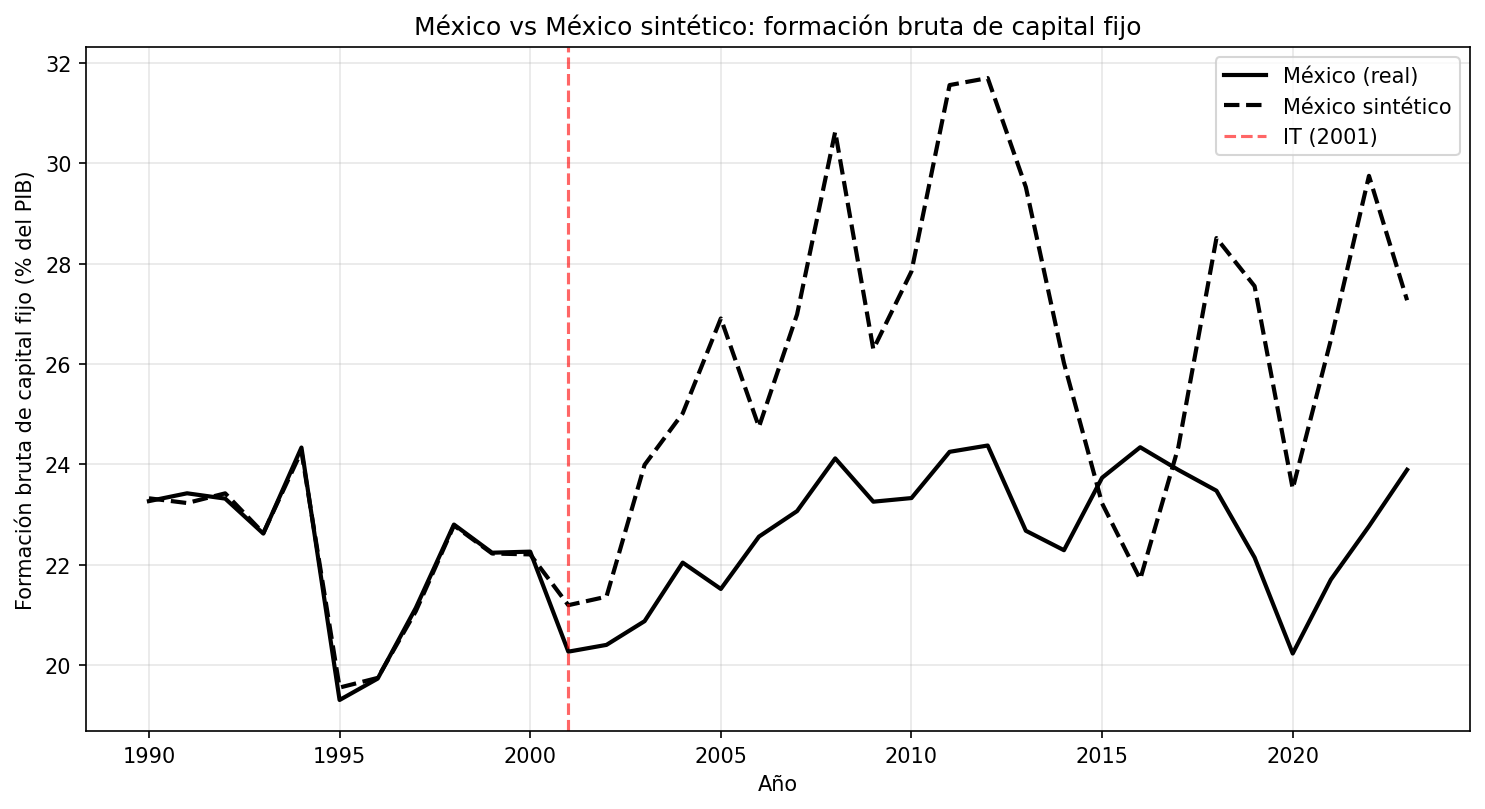

In [7]:
#| label: fig-path
#| fig-cap: "México observado vs México sintético: formación bruta de capital fijo."
scm.fig_path(res)
plt.show()

La @fig-gap traduce esa separación en el efecto estimado año a año (el *gap*: México observado menos sintético).

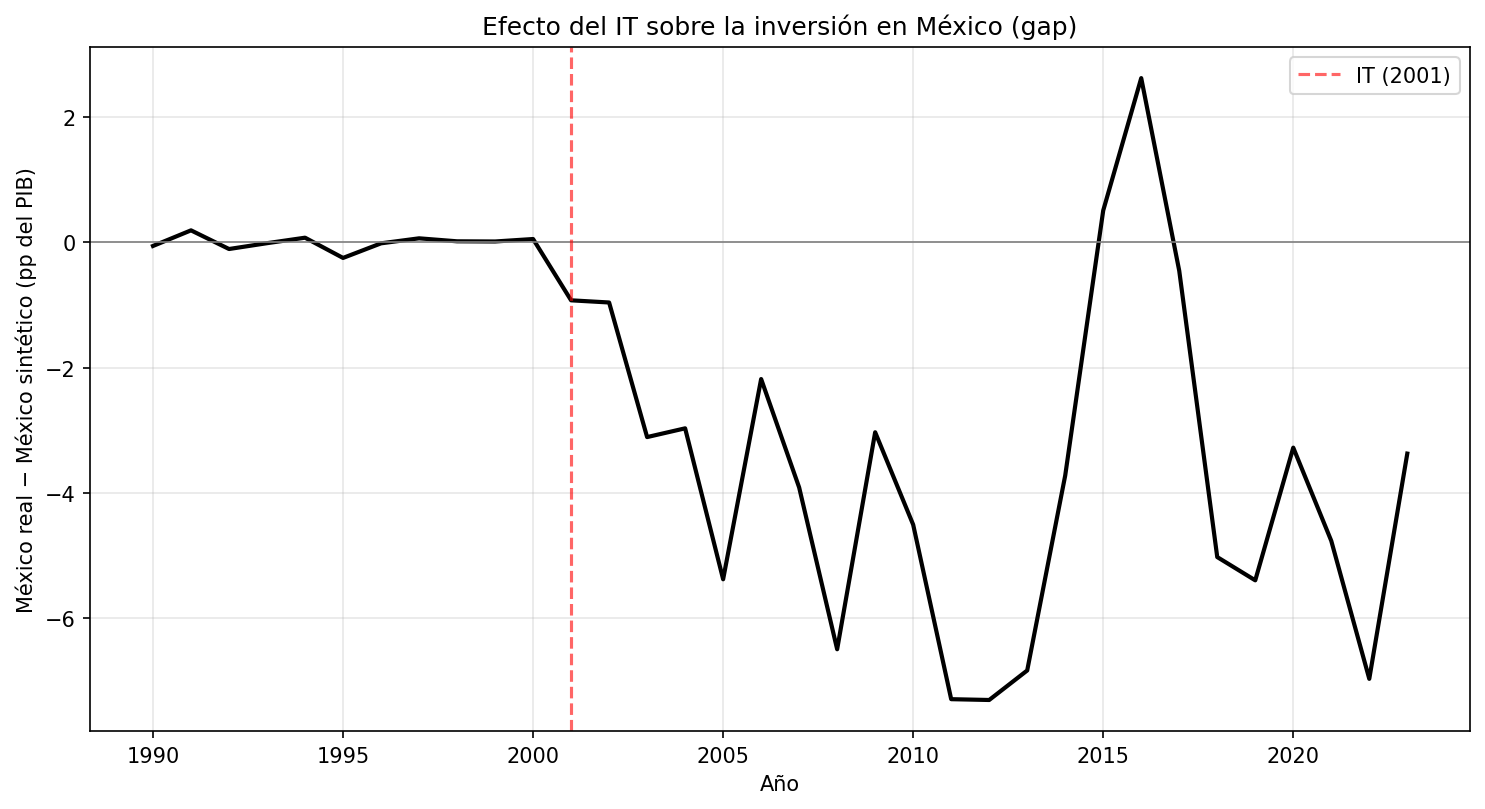

In [8]:
#| label: fig-gap
#| fig-cap: "Efecto estimado del IT sobre la inversión en México (gap, pp del PIB)."
scm.fig_gap(res)
plt.show()

El *gap* es persistentemente negativo durante todo el período post-2001, con un promedio cercano a $-3.7$ pp del PIB y un mínimo en torno a $-7.3$ pp hacia 2011–2012. La @tbl-effects compara nuestros efectos estimados con los de @mccloud2022 en años clave: la dirección coincide y las magnitudes son del mismo orden, con diferencias atribuibles a la actualización de datos y a la especificación non-OECD.

In [9]:
#| label: tbl-effects
#| tbl-cap: "Efecto estimado del IT sobre la inversión en México vs McCloud (2022), años clave."
Markdown(res.effects_table.to_markdown())

|   Año |   Estimado (pp) |   McCloud (pp) |   Diferencia |
|------:|----------------:|---------------:|-------------:|
|  2004 |           -2.97 |          -3.21 |         0.24 |
|  2005 |           -5.38 |          -3.54 |        -1.84 |
|  2007 |           -3.92 |          -4.79 |         0.87 |
|  2008 |           -6.5  |          -7.48 |         0.98 |
|  2011 |           -7.3  |          -6.25 |        -1.05 |

**Inferencia por placebos.** La @fig-placebos contrasta el *gap* de México (línea roja) con los *gaps* placebo de los donantes no-OCDE. El pseudo *p-value* asociado se reporta a continuación.

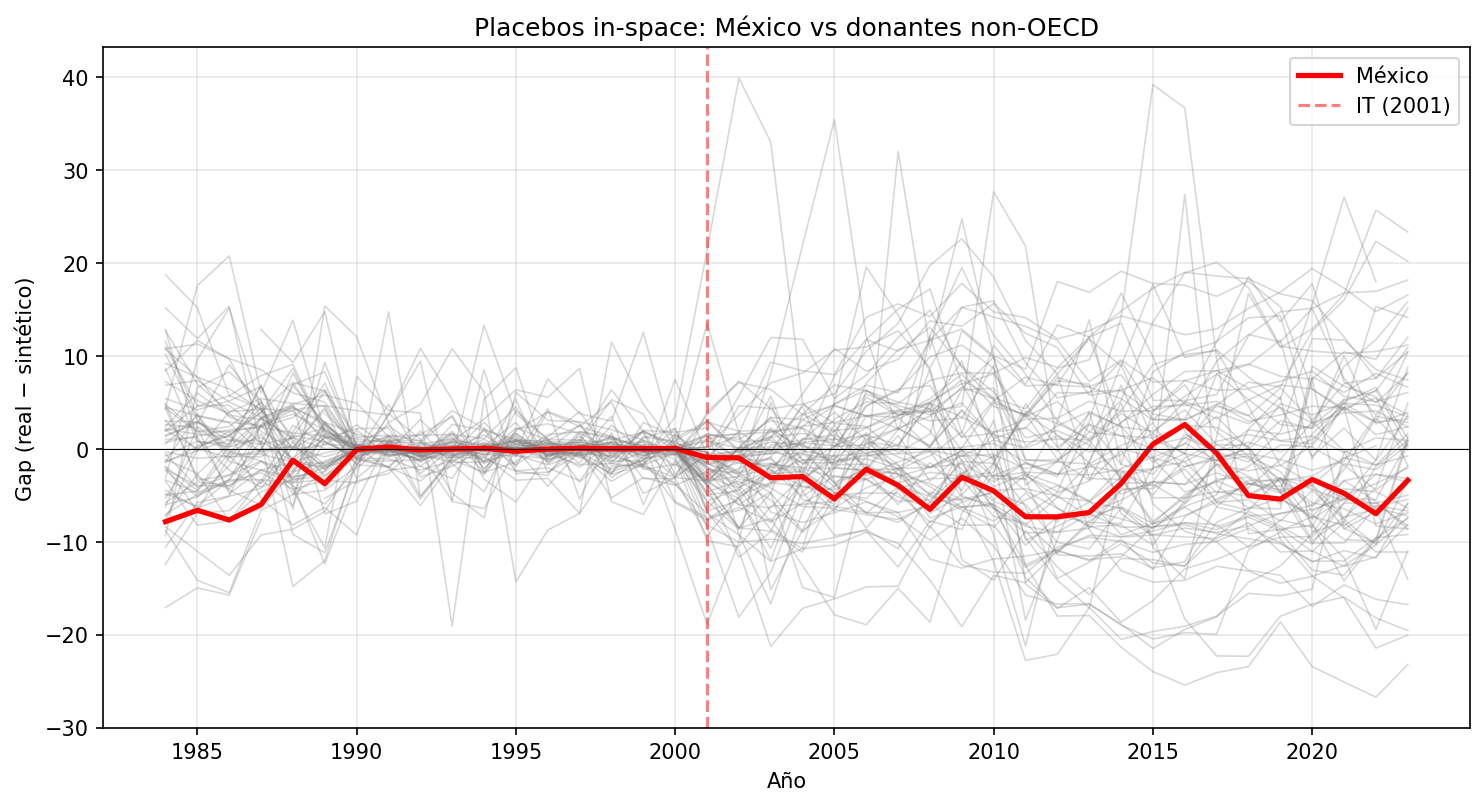

In [10]:
#| label: fig-placebos
#| fig-cap: "Placebos in-space: gap de México vs gaps de los donantes non-OECD."
#| echo: false
from pathlib import Path
out_dir = Path("out"); out_dir.mkdir(exist_ok=True)
fig_file = out_dir / "mexico_placebo_tests.png"
pval_file = out_dir / "placebo_pvalue.txt"

# Caché manual: el test de placebos es costoso (~83 estimaciones). Si la figura y
# el p-value ya existen en out/, se reutilizan; si no, se recomputan.
if fig_file.exists() and pval_file.exists():
    placebo_pvalue = float(pval_file.read_text().strip())
else:
    pb = scm.run_placebos(res)
    placebo_pvalue = pb.p_value
    pb.fig.savefig(fig_file, dpi=150, bbox_inches="tight")
    pval_file.write_text(str(placebo_pvalue))

from IPython.display import Image
Image(filename=str(fig_file))

El pseudo *p-value* de México es 0.75. Bajo la regla de decisión convencional [@adhikari2022], un valor superior a 0.10 implica que **no podemos rechazar la hipótesis nula** de ausencia de efecto al nivel usual. Es decir, aunque el *gap* de México es económicamente grande y persistentemente negativo, no es estadísticamente distinguible de los efectos placebo generados por economías que no adoptaron IT. La Sección 7 discute esta tensión y sus causas.

**Robustez.** La @tbl-robust compara la especificación base con dos alternativas: (i) incluir el ahorro bruto como predictor y (ii) extender la ventana pre-tratamiento a 1984–2000.

In [11]:
#| label: tbl-robust
#| tbl-cap: "Verificaciones de robustez: ajuste y efecto en 2008 por especificación."
import pandas as pd
specs = {
    "Base (non-OECD, 1990–2000)": scm.SCMConfig(),
    "+ ahorro bruto":             scm.SCMConfig(savings=True),
    "Ventana 1984–2000":          scm.SCMConfig(pre_start=1984),
}
rows = []
for name, cfg in specs.items():
    r = scm.estimate(cfg)
    gap2008 = float(r.gap.loc[2008]) if 2008 in r.gap.index else float("nan")
    rows.append({"Especificación": name,
                 "Donantes": len(r.donor_pool),
                 "RMSPE pre": round(r.rmspe, 4),
                 "Gap 2008 (pp)": round(gap2008, 2)})
Markdown(pd.DataFrame(rows).set_index("Especificación").to_markdown())

| Especificación             |   Donantes |   RMSPE pre |   Gap 2008 (pp) |
|:---------------------------|-----------:|------------:|----------------:|
| Base (non-OECD, 1990–2000) |         83 |      0.1074 |           -6.5  |
| + ahorro bruto             |         56 |      0.2707 |           -4.75 |
| Ventana 1984–2000          |         74 |      0.2895 |           -4.75 |

Ambas alternativas deterioran el ajuste pre-tratamiento (RMSPE mayor) sin alterar la conclusión cualitativa: el efecto estimado sigue siendo negativo. La especificación base —sin ahorro y con ventana 1990–2000— es la de mejor ajuste y la que adoptamos como principal.

# Discusión

**Una historia de dos lecturas.** El análisis descriptivo (Sección 4) mostraba que la inversión promedio de México fue mayor después de 2001 que antes. El control sintético invierte esa lectura: una vez que se construye el contrafactual apropiado, la inversión observada queda persistentemente por debajo de la que México habría alcanzado sin IT. La diferencia entre ambas lecturas es precisamente el valor del método: el aumento absoluto de la inversión en los 2000 fue, en buena medida, atribuible a factores comunes a las economías emergentes —que el sintético captura—, y no al régimen monetario. Relativo a ese contrafactual, la adopción del IT coincide con una inversión más baja.

**Interpretación económica de la magnitud.** Un *gap* del orden de $-6$ a $-7$ puntos porcentuales del PIB en los años de mayor separación no es trivial: representa una fracción considerable de la inversión anual y, acumulada sobre dos décadas, una cantidad económicamente importante de formación de capital no realizada. La persistencia del efecto —negativo en prácticamente todo el período post-2001, incluso tras la pandemia— sugiere que no se trata de un ajuste transitorio.

**Mecanismo.** Los resultados son coherentes con el mecanismo propuesto por @mccloud2022 y @bambe2023. El IT estimula la inversión a través del anclaje de expectativas; cuando ese anclaje no se materializa —porque el banco central tarda en construir credibilidad y la inflación se mantiene cerca del techo de la banda— el canal teórico no opera. A ello se suma un sistema financiero poco profundo [@boydsmith1998; @mccloud2022], que limita que la estabilidad de precios se transmita a la inversión productiva. México reúne ambas condiciones, lo que lo sitúa entre los casos donde el IT no solo es neutral, sino potencialmente contraproducente para la inversión.

**Comparación honesta con McCloud.** Nuestros resultados coinciden con @mccloud2022 en la **dirección** (efecto negativo) y en el **orden de magnitud** del efecto, pese a usar datos hasta 2023 y un *donor pool* no-OCDE. Esta concordancia es tranquilizadora: el hallazgo no depende críticamente de la ventana temporal ni de la composición exacta del *donor pool*. La diferencia más relevante es de **inferencia**: nuestro pseudo *p-value* (cercano a 0.75) es mucho mayor que el de McCloud (0.08–0.09). Dos factores lo explican. Primero, el período post-tratamiento es más largo (hasta 2023 vs 2017), lo que puede diluir el ratio entre el ajuste post y pre que sustenta el *p-value*. Segundo, y siguiendo la advertencia de @adhikari2022, la potencia de la inferencia por placebos es limitada y sensible a la composición del *donor pool*. En consecuencia, debemos ser cautos: el efecto es económicamente grande y robusto en signo, pero estadísticamente no distinguible de la distribución placebo al nivel convencional.

# Conclusiones

Este trabajo estimó el efecto causal de la adopción del *Inflation Targeting* en 2001 sobre la inversión doméstica en México, mediante el método de control sintético aplicado a un panel del Banco Mundial para 1984–2023. El hallazgo central es que, frente a un contrafactual construido con economías no-OCDE comparables, la inversión mexicana fue **persistentemente menor** tras la adopción del IT —del orden de $-3.7$ pp del PIB en promedio, con un mínimo cercano a $-7$ pp— pese a que en términos absolutos la inversión creció. La dirección y la magnitud coinciden con @mccloud2022.

**Veredicto sobre la hipótesis.** La evidencia es congruente con **H1** (efecto negativo) en el plano económico: el *gap* es negativo, persistente y de magnitud relevante. Sin embargo, en el plano estadístico no podemos rechazar **H0**: el pseudo *p-value* de la inferencia por placebos (≈0.75) está muy por encima del umbral convencional de 0.10 [@adhikari2022]. La conclusión honesta, por tanto, es matizada: los datos sugieren un efecto adverso económicamente importante, pero la inferencia por placebos —limitada por el tamaño del *donor pool* y por un período post-tratamiento largo— no permite descartar que se deba al azar.

**Limitaciones.** (i) El control sintético mide efectos reducidos, no mecanismos; no identifica directamente el papel de la credibilidad o del crédito. (ii) El pseudo *p-value* elevado limita la fuerza de la inferencia. (iii) No aislamos otros choques contemporáneos —el TLCAN (1994), reformas estructurales, la crisis financiera global de 2008— que pudieron afectar la inversión. (iv) El *donor pool* no-OCDE, aunque más comparable que la muestra completa, incluye economías de ingreso bajo que difieren de México en otras dimensiones.

**Extensiones.** Trabajo futuro podría: aplicar el *Augmented Synthetic Control* [@benmichael2021] para mejorar el ajuste y estimar un ATT con adopción escalonada; analizar explícitamente los mecanismos (canal de crédito, expectativas de inflación, inversión extranjera directa); comparar a México con otros adoptantes latinoamericanos (Chile, Colombia, Brasil, Perú); y desagregar la inversión por componentes (privada, pública, construcción) para identificar dónde se concentra el efecto.

# Referencias {.unnumbered}

::: {#refs}
:::